# Logistic Regression Model

## Student Health Risk Prediction

This notebook develops Logistic Regression as the first baseline classification model.

Logistic Regression is used as an interpretable benchmark before training more complex Computational Intelligence models such as Random Forest, Support Vector Machine, and MLP Neural Network.

Two configurations are evaluated:

1. Baseline Logistic Regression
2. Class-weighted Logistic Regression

Because the dataset is highly imbalanced, model selection is based not only on accuracy but also on balanced accuracy, macro precision, macro recall, macro F1-score, class-wise performance, and confusion matrices.

In [1]:
import os
import json
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
TRAIN_PATH = "../data/raw/train.csv"

train_df = pd.read_csv(TRAIN_PATH)

TARGET_COLUMN = "health_condition"
ID_COLUMN = "id"

print("Training shape:", train_df.shape)

Training shape: (690088, 15)


In [3]:
X = train_df.drop(columns=[TARGET_COLUMN, ID_COLUMN])
y = train_df[TARGET_COLUMN]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (690088, 13)
y shape: (690088,)


In [4]:
numerical_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

Numerical features: ['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 'step_count', 'exercise_duration', 'water_intake']
Categorical features: ['diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender']


In [5]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)

print("\nValidation target distribution:")
print(y_valid.value_counts(normalize=True).round(4) * 100)

X_train: (552070, 13)
X_valid: (138018, 13)

Validation target distribution:
health_condition
at-risk      85.87
unhealthy     8.36
fit           5.77
Name: proportion, dtype: float64


In [6]:
target_encoder = LabelEncoder()

y_train_encoded = target_encoder.fit_transform(y_train)
y_valid_encoded = target_encoder.transform(y_valid)

print("Classes:", target_encoder.classes_)

target_mapping = {
    class_name: int(encoded_value)
    for encoded_value, class_name in enumerate(target_encoder.classes_)
}

print("Target mapping:", target_mapping)

Classes: ['at-risk' 'fit' 'unhealthy']
Target mapping: {'at-risk': 0, 'fit': 1, 'unhealthy': 2}


In [7]:
numerical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_pipeline, numerical_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [8]:
def evaluate_model(model_name, model, X_valid, y_valid_encoded, target_encoder):
    y_pred = model.predict(X_valid)

    accuracy = accuracy_score(y_valid_encoded, y_pred)
    balanced_acc = balanced_accuracy_score(y_valid_encoded, y_pred)
    macro_precision = precision_score(
        y_valid_encoded,
        y_pred,
        average="macro",
        zero_division=0
    )
    macro_recall = recall_score(
        y_valid_encoded,
        y_pred,
        average="macro",
        zero_division=0
    )
    macro_f1 = f1_score(
        y_valid_encoded,
        y_pred,
        average="macro",
        zero_division=0
    )

    print("=" * 70)
    print(model_name)
    print("=" * 70)
    print("Accuracy:", round(accuracy, 4))
    print("Balanced Accuracy:", round(balanced_acc, 4))
    print("Macro Precision:", round(macro_precision, 4))
    print("Macro Recall:", round(macro_recall, 4))
    print("Macro F1:", round(macro_f1, 4))

    print("\nClassification Report:")
    print(
        classification_report(
            y_valid_encoded,
            y_pred,
            target_names=target_encoder.classes_,
            zero_division=0
        )
    )

    cm = confusion_matrix(y_valid_encoded, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=target_encoder.classes_
    )

    fig, ax = plt.subplots(figsize=(7, 6))
    disp.plot(ax=ax, values_format="d")
    ax.set_title(f"Confusion Matrix - {model_name}")
    plt.tight_layout()
    plt.show()

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Balanced Accuracy": balanced_acc,
        "Macro Precision": macro_precision,
        "Macro Recall": macro_recall,
        "Macro F1": macro_f1
    }

In [9]:
baseline_lr_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                solver="saga",
                n_jobs=-1,
                random_state=RANDOM_STATE
            )
        )
    ]
)

baseline_lr_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [10]:
baseline_lr_pipeline.fit(
    X_train,
    y_train_encoded
)

print("Baseline Logistic Regression trained successfully.")

Baseline Logistic Regression trained successfully.


Baseline Logistic Regression
Accuracy: 0.9526
Balanced Accuracy: 0.8428
Macro Precision: 0.904
Macro Recall: 0.8428
Macro F1: 0.8712

Classification Report:
              precision    recall  f1-score   support

     at-risk       0.96      0.98      0.97    118512
         fit       0.86      0.78      0.82      7961
   unhealthy       0.88      0.77      0.82     11545

    accuracy                           0.95    138018
   macro avg       0.90      0.84      0.87    138018
weighted avg       0.95      0.95      0.95    138018



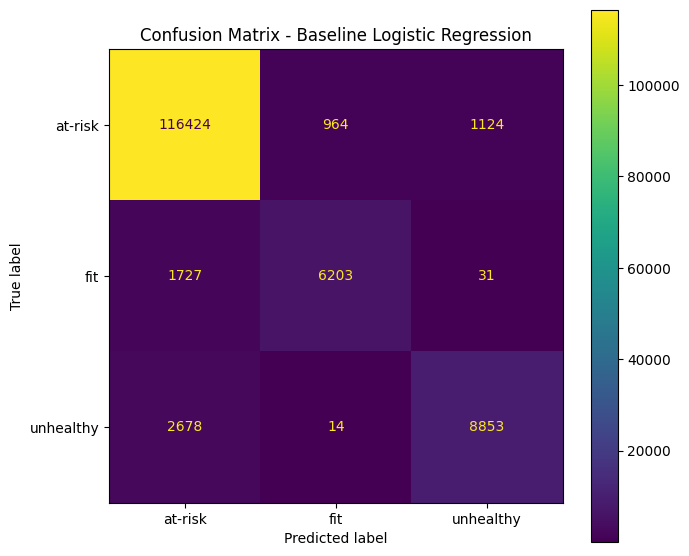

{'Model': 'Baseline Logistic Regression',
 'Accuracy': 0.9526293671839905,
 'Balanced Accuracy': 0.8427934890744094,
 'Macro Precision': 0.9039810385010224,
 'Macro Recall': 0.8427934890744094,
 'Macro F1': 0.8712305453980763}

In [11]:
baseline_lr_results = evaluate_model(
    "Baseline Logistic Regression",
    baseline_lr_pipeline,
    X_valid,
    y_valid_encoded,
    target_encoder
)

baseline_lr_results

In [12]:
weighted_lr_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                solver="saga",
                class_weight="balanced",
                n_jobs=-1,
                random_state=RANDOM_STATE
            )
        )
    ]
)

weighted_lr_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [13]:
weighted_lr_pipeline.fit(
    X_train,
    y_train_encoded
)

print("Class-weighted Logistic Regression trained successfully.")

Class-weighted Logistic Regression trained successfully.


Class-Weighted Logistic Regression
Accuracy: 0.8334
Balanced Accuracy: 0.8989
Macro Precision: 0.6325
Macro Recall: 0.8989
Macro F1: 0.7064

Classification Report:
              precision    recall  f1-score   support

     at-risk       0.99      0.82      0.89    118512
         fit       0.45      0.95      0.61      7961
   unhealthy       0.46      0.93      0.61     11545

    accuracy                           0.83    138018
   macro avg       0.63      0.90      0.71    138018
weighted avg       0.91      0.83      0.85    138018



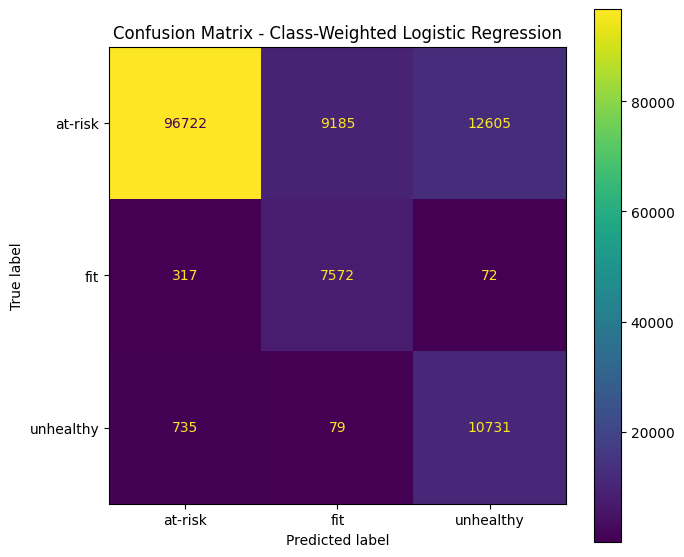

{'Model': 'Class-Weighted Logistic Regression',
 'Accuracy': 0.8334057876508861,
 'Balanced Accuracy': 0.8989222805065156,
 'Macro Precision': 0.6324746807685157,
 'Macro Recall': 0.8989222805065156,
 'Macro F1': 0.7063778071743584}

In [14]:
weighted_lr_results = evaluate_model(
    "Class-Weighted Logistic Regression",
    weighted_lr_pipeline,
    X_valid,
    y_valid_encoded,
    target_encoder
)

weighted_lr_results

In [15]:
lr_comparison = pd.DataFrame([
    baseline_lr_results,
    weighted_lr_results
])

lr_comparison = lr_comparison.round(4)

lr_comparison

,Model,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1
0,Baseline Logistic Regression,0.9526,0.8428,0.9040,0.8428,0.8712
1,Class-Weighted Logistic Regression,0.8334,0.8989,0.6325,0.8989,0.7064


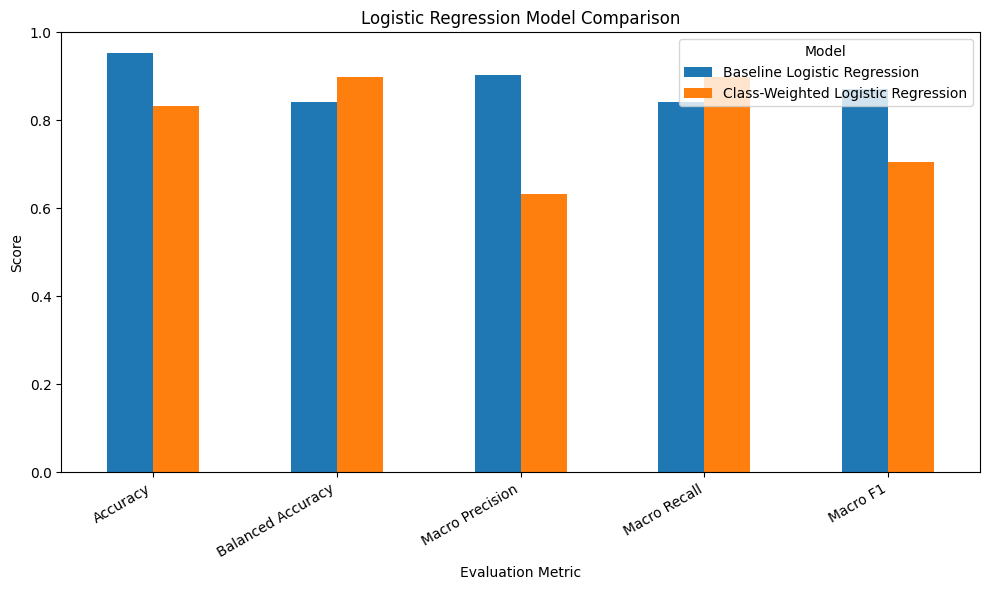

In [16]:
metrics_to_plot = [
    "Accuracy",
    "Balanced Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1"
]

plot_df = lr_comparison.set_index("Model")[metrics_to_plot]

ax = plot_df.T.plot(kind="bar", figsize=(10, 6))

ax.set_title("Logistic Regression Model Comparison")
ax.set_xlabel("Evaluation Metric")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)

plt.xticks(rotation=30, ha="right")
plt.legend(title="Model")
plt.tight_layout()
plt.show()

In [17]:
param_grid = {
    "model__C": [0.1, 1.0, 10.0],
    "model__penalty": ["l2"]
}

tuned_lr_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                solver="saga",
                class_weight="balanced",
                n_jobs=-1,
                random_state=RANDOM_STATE
            )
        )
    ]
)

lr_grid_search = GridSearchCV(
    estimator=tuned_lr_pipeline,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=3,
    n_jobs=-1,
    verbose=1
)

lr_grid_search.fit(X_train, y_train_encoded)

print("Best Parameters:")
print(lr_grid_search.best_params_)

print("Best CV Macro F1:")
print(round(lr_grid_search.best_score_, 4))

Fitting 3 folds for each of 3 candidates, totalling 9 fits
Best Parameters:
{'model__C': 10.0, 'model__penalty': 'l2'}
Best CV Macro F1:
0.7063


Tuned Logistic Regression
Accuracy: 0.8334
Balanced Accuracy: 0.8989
Macro Precision: 0.6325
Macro Recall: 0.8989
Macro F1: 0.7064

Classification Report:
              precision    recall  f1-score   support

     at-risk       0.99      0.82      0.89    118512
         fit       0.45      0.95      0.61      7961
   unhealthy       0.46      0.93      0.61     11545

    accuracy                           0.83    138018
   macro avg       0.63      0.90      0.71    138018
weighted avg       0.91      0.83      0.85    138018



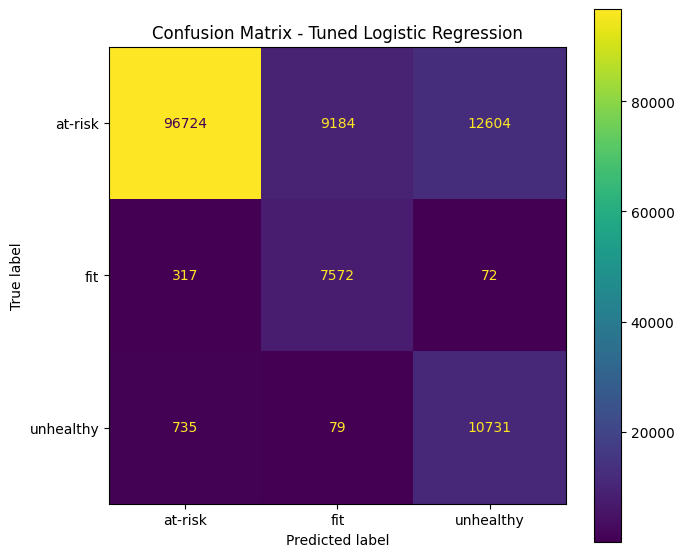

{'Model': 'Tuned Logistic Regression',
 'Accuracy': 0.8334202785143967,
 'Balanced Accuracy': 0.8989279058159076,
 'Macro Precision': 0.6324901876314816,
 'Macro Recall': 0.8989279058159076,
 'Macro F1': 0.7063952808047964}

In [18]:
best_lr_model = lr_grid_search.best_estimator_

tuned_lr_results = evaluate_model(
    "Tuned Logistic Regression",
    best_lr_model,
    X_valid,
    y_valid_encoded,
    target_encoder
)

tuned_lr_results

In [19]:
final_lr_comparison = pd.DataFrame([
    baseline_lr_results,
    weighted_lr_results,
    tuned_lr_results
]).round(4)

final_lr_comparison

,Model,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1
0,Baseline Logistic Regression,0.9526,0.8428,0.9040,0.8428,0.8712
1,Class-Weighted Logistic Regression,0.8334,0.8989,0.6325,0.8989,0.7064
2,Tuned Logistic Regression,0.8334,0.8989,0.6325,0.8989,0.7064


In [24]:
# Create comparison table using full-precision results
lr_selection_df = pd.DataFrame([
    baseline_lr_results,
    weighted_lr_results,
    tuned_lr_results
])

# Select best model using official competition metric
best_lr_row = lr_selection_df.sort_values(
    by="Balanced Accuracy",
    ascending=False
).iloc[0]

best_lr_name = best_lr_row["Model"]
best_lr_balanced_accuracy = best_lr_row["Balanced Accuracy"]

print("Selection Metric: Balanced Accuracy")
print("Best Logistic Regression Variant:", best_lr_name)
print(
    "Best Balanced Accuracy:",
    round(best_lr_balanced_accuracy, 6)
)

if best_lr_name == "Baseline Logistic Regression":
    final_lr_model = baseline_lr_pipeline

elif best_lr_name == "Class-Weighted Logistic Regression":
    final_lr_model = weighted_lr_pipeline

else:
    final_lr_model = best_lr_model

Selection Metric: Balanced Accuracy
Best Logistic Regression Variant: Tuned Logistic Regression
Best Balanced Accuracy: 0.898928


In [25]:
os.makedirs("../models", exist_ok=True)
os.makedirs("../outputs/metrics", exist_ok=True)

joblib.dump(
    final_lr_model,
    "../models/logistic_regression.pkl"
)

joblib.dump(
    target_encoder,
    "../models/target_encoder.pkl"
)

final_lr_comparison.to_csv(
    "../outputs/metrics/logistic_regression_results.csv",
    index=False
)

print("Final Logistic Regression model saved.")
print("Target encoder saved.")
print("Logistic Regression results saved.")

Final Logistic Regression model saved.
Target encoder saved.
Logistic Regression results saved.


## Logistic Regression Conclusion

Three Logistic Regression configurations were evaluated: a baseline model, a class-weighted model, and a tuned class-weighted model. The baseline model achieved the highest overall accuracy (0.9526) and Macro F1-score (0.8712), demonstrating strong aggregate classification performance. However, its Balanced Accuracy was lower (0.8428), indicating weaker sensitivity across the minority health-condition classes.

Introducing balanced class weights substantially improved minority-class recognition. The class-weighted model increased Balanced Accuracy to 0.8989, with recall values of approximately 0.95 for the `fit` class and 0.93 for the `unhealthy` class. This improvement was accompanied by lower precision and a reduced Macro F1-score, illustrating a clear trade-off between minority-class sensitivity and false-positive errors.

Hyperparameter tuning selected `C = 10.0` with L2 regularisation. The tuned model achieved the highest Balanced Accuracy of approximately 0.8989, although its performance was almost identical to the untuned class-weighted configuration. This suggests that class weighting had a substantially greater effect than adjustment of the regularisation parameter within the tested search space.

Because Balanced Accuracy is the official competition evaluation metric, the tuned Logistic Regression model was selected as the final Logistic Regression candidate. The results also demonstrate why raw accuracy alone is insufficient for this highly imbalanced three-class dataset.